# Week 5 · Business Category Analysis
Business Rehearsal Outcome Predictor · Spring 2026

Research question: does a global model generalize, or do **retail**, **apparel**,
and **B2B** need separate models?

Approach: train XGBoost (best single-target model from Week 4) on each category
independently and compare MAPE against the global model.

In [1]:
import os, sys
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.figsize': (12, 4),
                     'axes.spines.top': False, 'axes.spines.right': False})

from models.xgboost_model import (
    load_features, temporal_split, train_xgboost, print_results
)

TARGETS = [
    'label_inventory_delta',
    'label_cashflow_delta',
    'label_order_velocity_delta',
]
SHORT = {
    'label_inventory_delta':      'Inventory',
    'label_cashflow_delta':       'Cash Flow',
    'label_order_velocity_delta': 'Order Velocity',
}


In [2]:
# Train global model once — this is our benchmark
df = load_features('data/processed/training_data.csv')
train_all, test_all = temporal_split(df)

print('=== Global model (all categories) ===')
global_results = train_xgboost(train_all, test_all)
print_results(global_results)


Loaded 2,100 rows from data/processed/training_data.csv
  Date range: 2025-11-30 → 2026-08-17
  Businesses: 150
  Branches:   2,100

Temporal split at 2026-06-26 (80%/20%)
  Train rows: 1,677  |  Test rows: 423
=== Global model (all categories) ===

Training: inventory
  point model done
  lower quantile (0.1) done
  upper quantile (0.9) done

Training: cashflow
  point model done
  lower quantile (0.1) done
  upper quantile (0.9) done

Training: order_velocity
  point model done
  lower quantile (0.1) done
  upper quantile (0.9) done

Target                        MAPE    Calibration (80% CI)
───────────────────────────────────────────────────────────
  Inventory Delta         123.4%    0.68  (target: 0.80)
  Cash Flow Delta          90.9%    0.75  (target: 0.80)
  Order Velocity Delta     90.5%    0.70  (target: 0.80)

Interpretation guide:
  MAPE < 15%   → strong; beats baseline comfortably
  MAPE 15-30%  → acceptable, on par with or better than baseline
  MAPE > 30%   → weak — revi

## Per-category models
Each category gets its own XGBoost trained and evaluated on category-filtered data,
using the same temporal 80/20 split.

In [3]:
CATEGORIES = ['retail', 'apparel', 'b2b']
cat_results = {}

for cat in CATEGORIES:
    df_cat = df[df['category'] == cat].copy()
    train_c, test_c = temporal_split(df_cat)
    print(f'\n=== {cat.upper()} ===')
    cat_results[cat] = train_xgboost(train_c, test_c)
    print_results(cat_results[cat])



Temporal split at 2026-06-21 (80%/20%)
  Train rows: 549  |  Test rows: 138

=== RETAIL ===

Training: inventory
  point model done
  lower quantile (0.1) done
  upper quantile (0.9) done

Training: cashflow
  point model done
  lower quantile (0.1) done
  upper quantile (0.9) done

Training: order_velocity
  point model done
  lower quantile (0.1) done
  upper quantile (0.9) done

Target                        MAPE    Calibration (80% CI)
───────────────────────────────────────────────────────────
  Inventory Delta         280.8%    0.59  (target: 0.80)
  Cash Flow Delta          93.3%    0.78  (target: 0.80)
  Order Velocity Delta    118.8%    0.59  (target: 0.80)

Interpretation guide:
  MAPE < 15%   → strong; beats baseline comfortably
  MAPE 15-30%  → acceptable, on par with or better than baseline
  MAPE > 30%   → weak — revisit hyperparameters or feature set

  Calibration near 0.80 → quantile intervals are honest
  Calibration >> 0.80   → intervals too wide (conservative)
  Ca

## Global vs per-category — MAPE comparison
A lower per-category MAPE means the category benefits from specialization.

In [ ]:
rows = []
for target in TARGETS:
    row = {'Target': SHORT[target], 'Global': round(global_results[target]['mape'], 1)}
    for cat in CATEGORIES:
        row[cat.capitalize()] = round(cat_results[cat][target]['mape'], 1)
    rows.append(row)

compare = pd.DataFrame(rows).set_index('Target')
display(compare)

# Delta: per-category MAPE minus global MAPE (negative = category model wins)
print('\nDelta from global (negative = per-category wins):')
cat_cols = [c.capitalize() for c in CATEGORIES]
delta = compare[cat_cols].subtract(compare["Global"], axis=0)
display(delta.round(1))


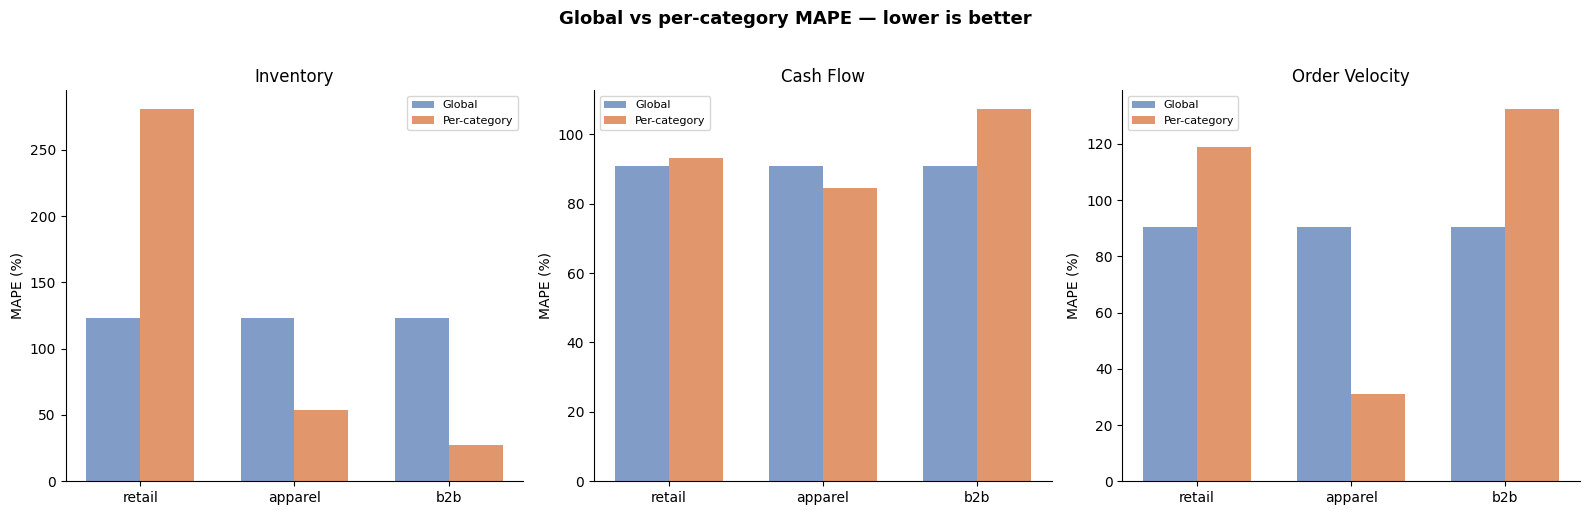

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x  = np.arange(len(CATEGORIES))
w  = 0.35

for ax, target in zip(axes, TARGETS):
    global_mape = global_results[target]['mape']
    cat_mapes   = [cat_results[c][target]['mape'] for c in CATEGORIES]

    ax.bar(x - w/2, [global_mape]*3, w, label='Global', color='#4C72B0', alpha=0.7)
    ax.bar(x + w/2, cat_mapes,       w, label='Per-category', color='#DD8452', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(CATEGORIES)
    ax.set_ylabel('MAPE (%)')
    ax.set_title(SHORT[target])
    ax.legend(fontsize=8)

plt.suptitle('Global vs per-category MAPE — lower is better',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


## Top features differ by category — does XGBoost learn different patterns?

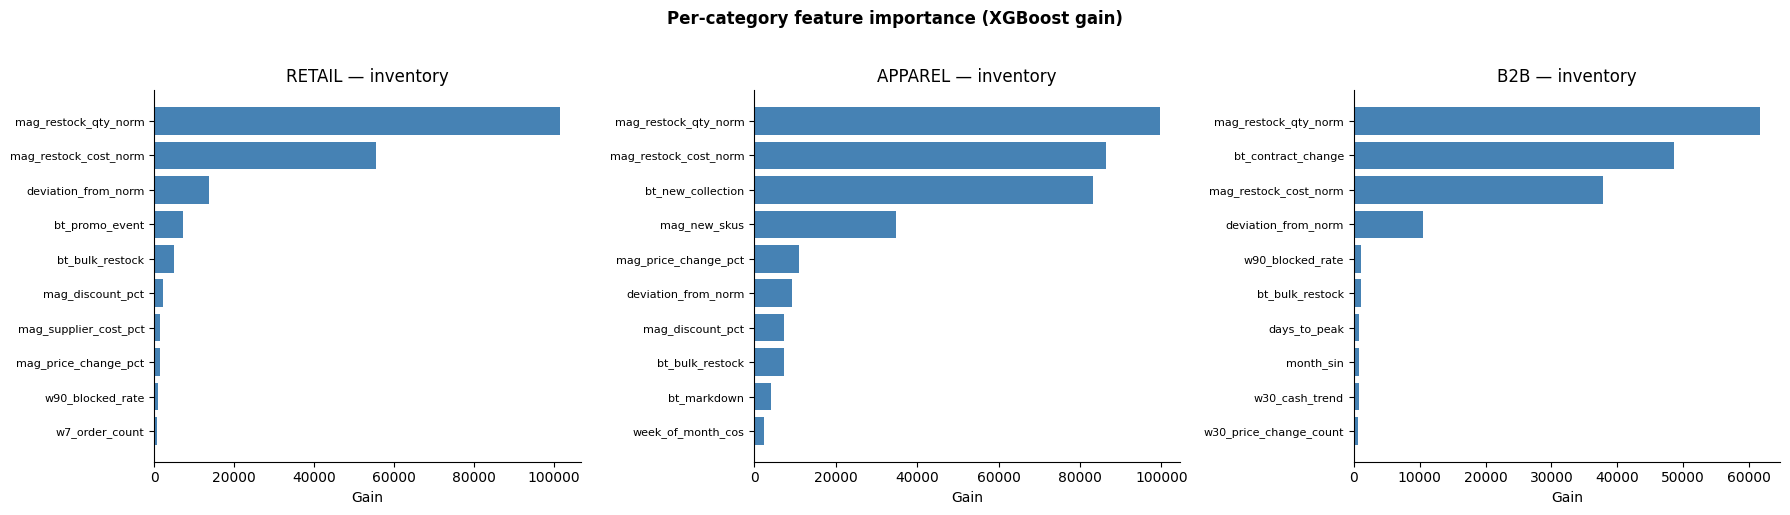

In [6]:
target = 'label_inventory_delta'
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cat in zip(axes, CATEGORIES):
    scores = cat_results[cat][target]['model_point'] \
             .get_booster().get_score(importance_type='gain')
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:10]
    if not ranked:
        ax.set_title(f'{cat} (no scores)'); continue
    feats, gains = zip(*ranked)
    ax.barh(range(len(feats)), gains, color='steelblue')
    ax.set_yticks(range(len(feats)))
    ax.set_yticklabels(feats, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('Gain')
    ax.set_title(f'{cat.upper()} — inventory')

plt.suptitle('Per-category feature importance (XGBoost gain)',
             fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
